# **Load Data**

In [130]:
import pandas as pd
df = pd.read_csv('/content/transJakarta_tweets.csv')  # ganti nama kolom teks kalau beda

print(df.head())  # Menampilkan seluruh isi data

   conversation_id_str                      created_at  favorite_count  \
0         2.039131e+18  Tue Mar 31 23:59:55 +0000 2026               0   
1         2.039109e+18  Tue Mar 31 22:32:33 +0000 2026               1   
2         2.038921e+18  Tue Mar 31 10:05:26 +0000 2026               5   
3         2.039050e+18  Tue Mar 31 18:41:12 +0000 2026               1   
4         2.039055e+18  Tue Mar 31 18:59:22 +0000 2026               2   

                                           full_text        id_str  \
0  Ini belum dibenerin juga min @PT_Transjakarta ...  2.039131e+18   
1  #INFOTRANSJAKARTA | Layanan Mikrotrans JAK 07:...  2.039109e+18   
2  Perjalananmu GRATIS buat naik TJ KRL LRT &amp;...  2.038921e+18   
3  #INFOTRANSJAKARTA | Koridor 1: Blok M - Kota m...  2.039050e+18   
4  #INFOTRANSJAKARTA | Koridor 2: Pulo Gadung - M...  2.039055e+18   

                                           image_url in_reply_to_screen_name  \
0    https://pbs.twimg.com/media/HExyeAqbEAAHZyB.jpg  

In [131]:
print(df.info()) #Struktur data
print("Jumlah data:", len(df)) #Jumlah data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      130 non-null    float64
 1   created_at               130 non-null    object 
 2   favorite_count           130 non-null    int64  
 3   full_text                130 non-null    object 
 4   id_str                   130 non-null    float64
 5   image_url                27 non-null     object 
 6   in_reply_to_screen_name  21 non-null     object 
 7   lang                     130 non-null    object 
 8   location                 0 non-null      float64
 9   quote_count              130 non-null    int64  
 10  reply_count              130 non-null    int64  
 11  retweet_count            130 non-null    int64  
 12  tweet_url                130 non-null    object 
 13  user_id_str              130 non-null    float64
 14  username                 0

# **Cleaning Text**

In [132]:
import re

def clean_text(full_text):
    text = full_text.lower()  # 1. Lowercase
    text = re.sub(r"http\S+", "", text) # 2. Hapus URL/Link
    text = re.sub(r"@\w+", "", text)  # 3. Hapus Mention (@username)
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)  # 4. Hapus Emoji dan Spesial Karakter (tapi SIMPAN angka & spasi) | ^a-zA-Z0-9\s = hapus selain huruf, angka, & spasi
    text = re.sub(r"\s+", " ", text).strip() # 5. Hapus spasi berlebih
    return text

df = df.drop_duplicates(subset=['full_text']).reset_index(drop=True)  # 6. Hapus data yang full_text-nya duplikat

df['clean_text'] = df['full_text'].apply(clean_text)

In [133]:
df[['full_text', 'clean_text']].head()

,full_text,clean_text
0,Ini belum dibenerin juga min @PT_Transjakarta ...,ini belum dibenerin juga min kasihan lho petug...
1,#INFOTRANSJAKARTA | Layanan Mikrotrans JAK 07:...,infotransjakarta layanan mikrotrans jak 07 tan...
2,Perjalananmu GRATIS buat naik TJ KRL LRT &amp;...,perjalananmu gratis buat naik tj krl lrt amp m...
3,#INFOTRANSJAKARTA | Koridor 1: Blok M - Kota m...,infotransjakarta koridor 1 blok m kota mengala...
4,#INFOTRANSJAKARTA | Koridor 2: Pulo Gadung - M...,infotransjakarta koridor 2 pulo gadung monumen...


# **Trigram**

In [134]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Trigram
vectorizer = CountVectorizer(ngram_range=(3, 3), token_pattern=r'\b\w+\b')
X = vectorizer.fit_transform(df['clean_text'])

trigram_counts = X.toarray().sum(axis=0)
trigram_features = vectorizer.get_feature_names_out()
trigram_df = pd.DataFrame({
  'trigram': trigram_features,
  'count': trigram_counts
})

trigram_df = trigram_df.sort_values(by='count', ascending=False)
trigram_df.head(10)

,trigram,count
1838,pantau informasi terkini,15
961,informasi terkini layanan,14
2287,terkini layanan transjakarta,13
1384,layanan transjakarta melalui,12
2425,transjakarta melalui x,11
1536,melalui x pttransjakarta,8
1568,mengalami pengalihan rute,7
2546,x pttransjakarta instagram,7
1882,pengalihan pantau informasi,6
1308,koridor 4 pulo,6


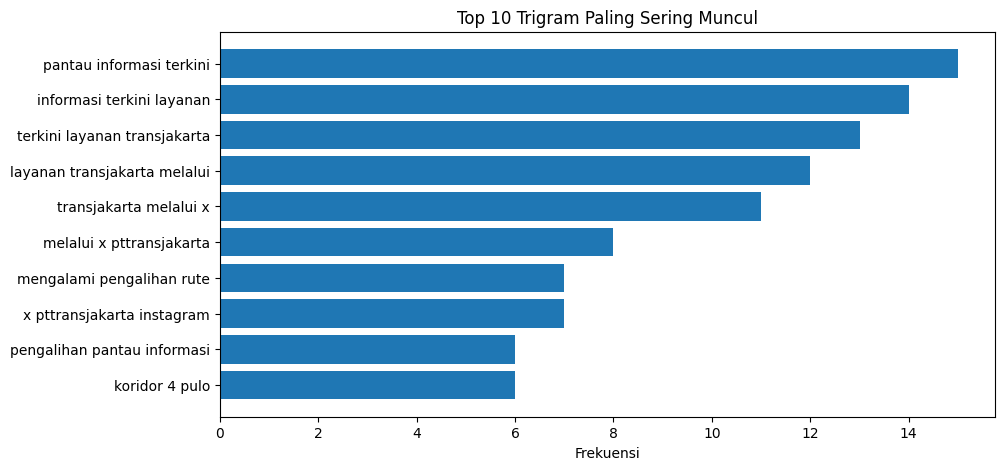

In [135]:
# Visualisasi Diagram
import matplotlib.pyplot as plt

top_trigram = trigram_df.head(10)
plt.figure(figsize=(10,5))

plt.barh(top_trigram['trigram'], top_trigram['count'])
plt.gca().invert_yaxis()
plt.title("Top 10 Trigram Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.show()

**Kamus InSet - Lexicon based**

In [136]:
pos_lex = pd.read_csv(
  '/content/positive.tsv',
  sep='\t',
  engine='python'
)

neg_lex = pd.read_csv(
  '/content/negative.tsv',
  sep='\t',
  engine='python'
)

In [137]:
print(pos_lex.columns)
print(pos_lex.head())

Index(['word', 'weight'], dtype='object')
        word  weight
0        hai       3
1    merekam       2
2  ekstensif       3
3  paripurna       1
4     detail       2


In [138]:
positive_words = dict(zip(pos_lex['word'], pos_lex['weight']))
negative_words = dict(zip(neg_lex['word'], neg_lex['weight']))

In [139]:
def sentiment_inset(text):
  score = 0

  for word in str(text).split():
    if word in positive_words:
      score += positive_words[word]
    elif word in negative_words:
      score += negative_words[word]
  return score

df['sentiment_score'] = df['clean_text'].apply(sentiment_inset)

In [140]:
def label(score):
  if score > 0:
    return 'Positif'
  elif score < 0:
    return 'Negatif'
  else:
    return 'Netral'
df['sentiment_label'] = df['sentiment_score'].apply(label)

In [141]:
df[['full_text', 'clean_text', 'sentiment_score', 'sentiment_label']].head()

,full_text,clean_text,sentiment_score,sentiment_label
0,Ini belum dibenerin juga min @PT_Transjakarta ...,ini belum dibenerin juga min kasihan lho petug...,-2,Negatif
1,#INFOTRANSJAKARTA | Layanan Mikrotrans JAK 07:...,infotransjakarta layanan mikrotrans jak 07 tan...,5,Positif
2,Perjalananmu GRATIS buat naik TJ KRL LRT &amp;...,perjalananmu gratis buat naik tj krl lrt amp m...,12,Positif
3,#INFOTRANSJAKARTA | Koridor 1: Blok M - Kota m...,infotransjakarta koridor 1 blok m kota mengala...,11,Positif
4,#INFOTRANSJAKARTA | Koridor 2: Pulo Gadung - M...,infotransjakarta koridor 2 pulo gadung monumen...,16,Positif


In [142]:
sentimen_summary = df['sentiment_label'].value_counts().reset_index()
sentimen_summary.columns = ['Sentimen', 'Jumlah']
print(sentimen_summary)

  Sentimen  Jumlah
0  Positif      78
1  Negatif      41
2   Netral      11


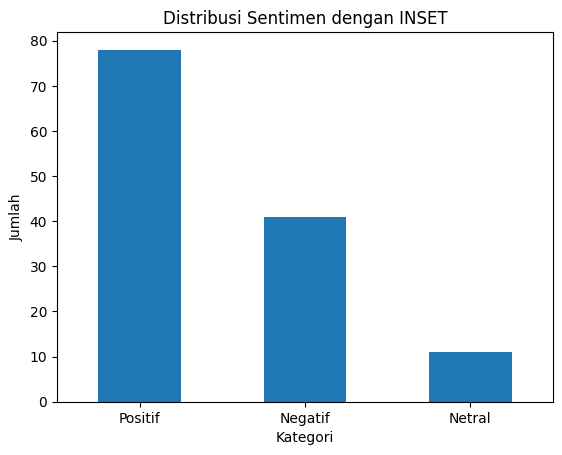

In [143]:
import matplotlib.pyplot as plt

df['sentiment_label'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen dengan INSET")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

**Sentimen untuk trigram tertentu**

In [144]:
topic = "pantau informasi terkini"
topic_df = df[df['clean_text'].str.contains(topic, na=False)]
topic_df['sentiment_label'].value_counts()

,count
sentiment_label,
Positif,15


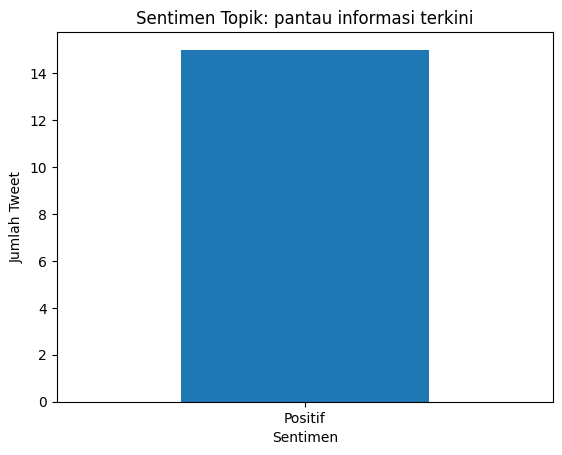

In [145]:
import matplotlib.pyplot as plt
topic_df['sentiment_label'].value_counts().plot(kind='bar')
plt.title(f"Sentimen Topik: {topic}")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah Tweet")
plt.xticks(rotation=0)
plt.show()

**Sentimen berdasarkan TOP TRIGRAM otomatis**

In [146]:
top_trigram = trigram_df.head(10)['trigram'].tolist()
print(top_trigram)

['pantau informasi terkini', 'informasi terkini layanan', 'terkini layanan transjakarta', 'layanan transjakarta melalui', 'transjakarta melalui x', 'melalui x pttransjakarta', 'mengalami pengalihan rute', 'x pttransjakarta instagram', 'pengalihan pantau informasi', 'koridor 4 pulo']


In [147]:
for topic in top_trigram:
  print(f"\nTopik: {topic}")
  topic_df = df[df['clean_text'].str.contains(topic, na=False, case=False)]
  print(topic_df['sentiment_label'].value_counts())


Topik: pantau informasi terkini
sentiment_label
Positif    15
Name: count, dtype: int64

Topik: informasi terkini layanan
sentiment_label
Positif    14
Name: count, dtype: int64

Topik: terkini layanan transjakarta
sentiment_label
Positif    13
Name: count, dtype: int64

Topik: layanan transjakarta melalui
sentiment_label
Positif    11
Name: count, dtype: int64

Topik: transjakarta melalui x
sentiment_label
Positif    11
Name: count, dtype: int64

Topik: melalui x pttransjakarta
sentiment_label
Positif    8
Name: count, dtype: int64

Topik: mengalami pengalihan rute
sentiment_label
Positif    7
Name: count, dtype: int64

Topik: x pttransjakarta instagram
sentiment_label
Positif    7
Name: count, dtype: int64

Topik: pengalihan pantau informasi
sentiment_label
Positif    6
Name: count, dtype: int64

Topik: koridor 4 pulo
sentiment_label
Positif    6
Name: count, dtype: int64
